In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Working directory:", os.getcwd())

df = pd.read_csv("../data/raw/loan_default.csv")

df.head()
df.info()

print("Duplicates:", df.duplicated().sum())
print(df.describe())

df["Default"].value_counts(normalize=True) * 100


Working directory: c:\Users\natta\Downloads\Loan_default\Loan_default\notebooks
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

In [36]:
df.isna().sum().sort_values(ascending=False)


LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Default
0    225694
1     29653
Name: count, dtype: int64
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


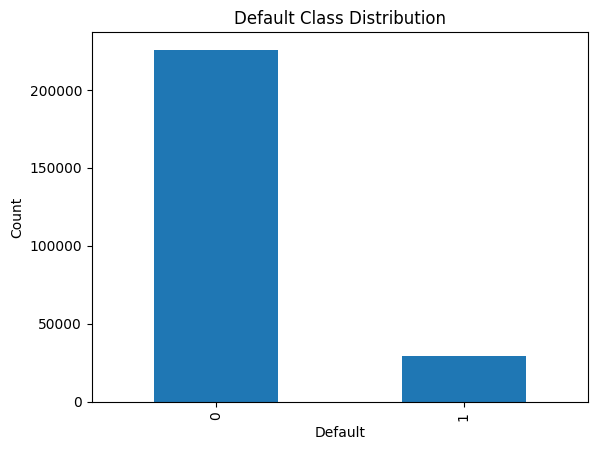

In [37]:
default_counts = df["Default"].value_counts()
default_pct = df["Default"].value_counts(normalize=True) * 100
print(default_counts)
print(default_pct)

default_counts.plot(kind="bar")
plt.title("Default Class Distribution")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()


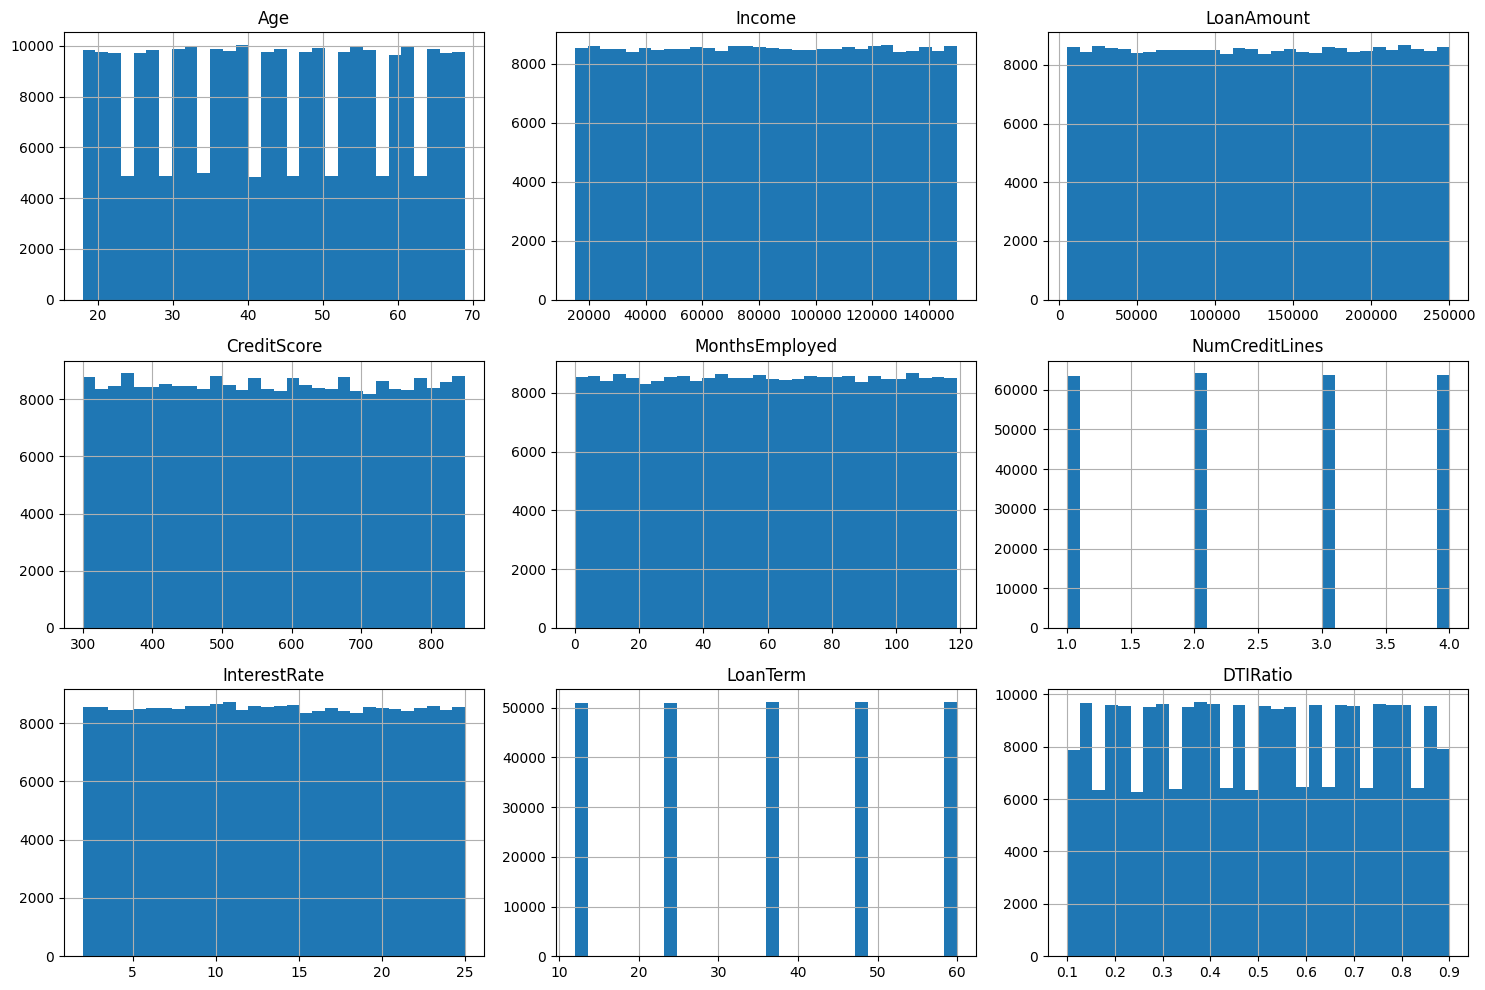

In [38]:
num_cols = [
    "Age", "Income", "LoanAmount", "CreditScore",
    "MonthsEmployed", "NumCreditLines", "InterestRate",
    "LoanTerm", "DTIRatio"
]

df[num_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()



=== Education ===
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64


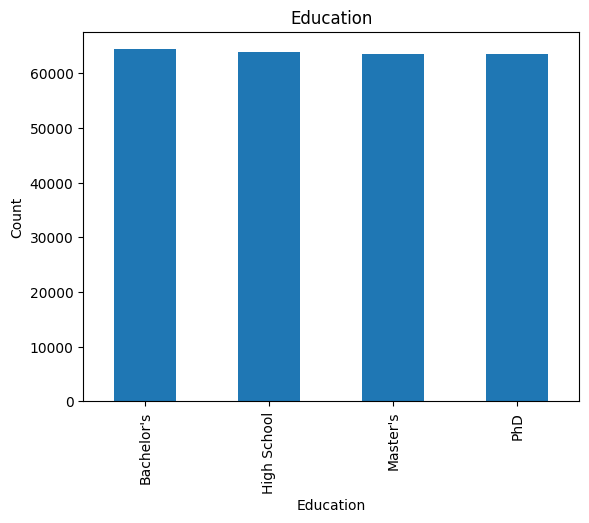


=== EmploymentType ===
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64


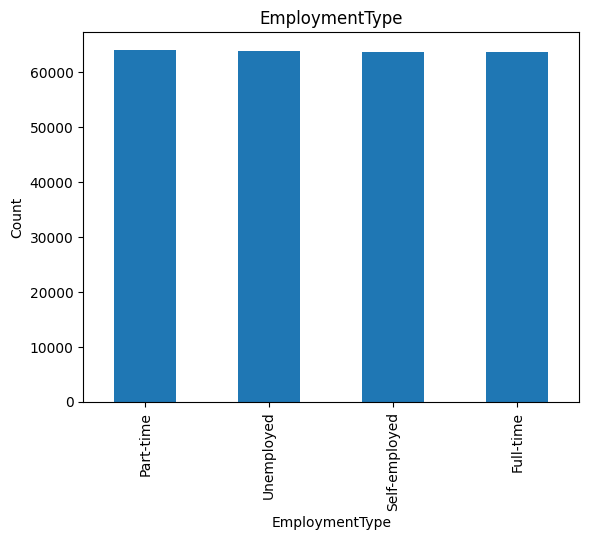


=== MaritalStatus ===
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64


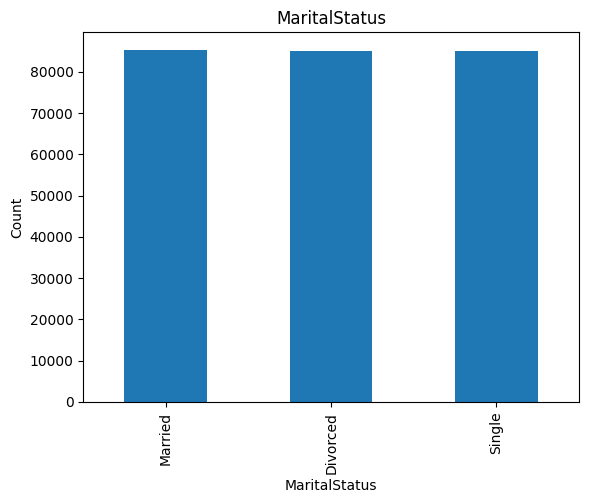


=== HasMortgage ===
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64


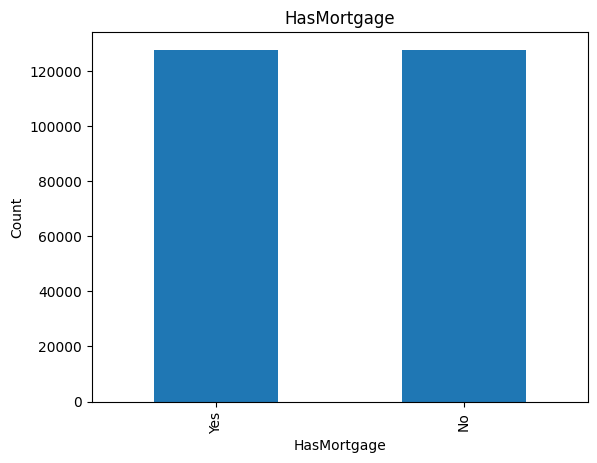


=== HasDependents ===
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64


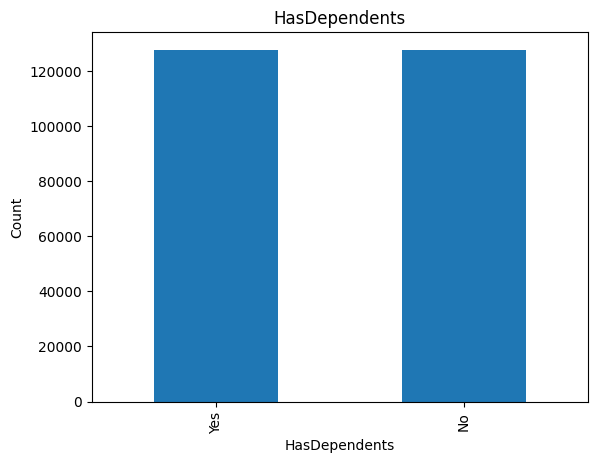


=== LoanPurpose ===
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64


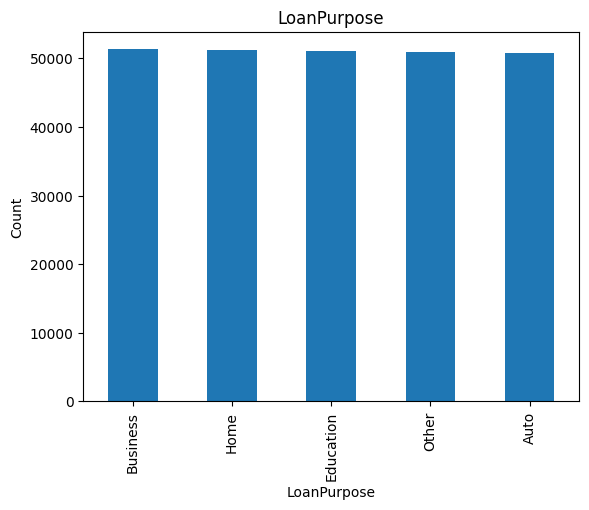


=== HasCoSigner ===
HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64


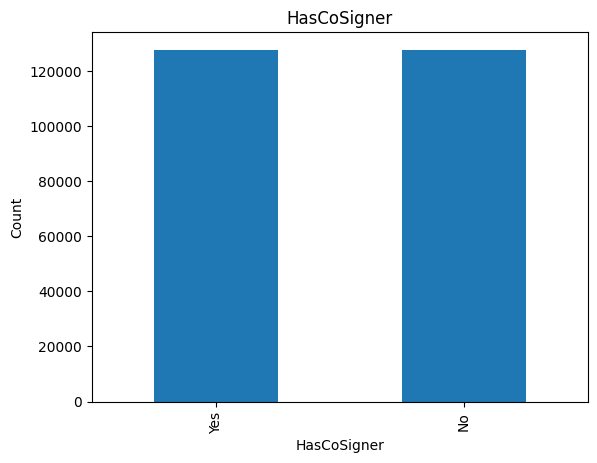

In [40]:
cat_cols = [
    "Education", "EmploymentType", "MaritalStatus",
    "HasMortgage", "HasDependents", "LoanPurpose", "HasCoSigner"
]

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.ylabel("Count")
    plt.show()


In [41]:
df.groupby("Default")[num_cols].mean().T


Default,0,1
Age,44.409962,36.559539
Income,83899.165995,71844.722659
LoanAmount,125353.656017,144515.311469
CreditScore,576.232270,559.286143
MonthsEmployed,60.764721,50.235457
NumCreditLines,2.489566,2.588338
InterestRate,13.176994,15.896227
LoanTerm,36.022544,36.051394
DTIRatio,0.498602,0.512467


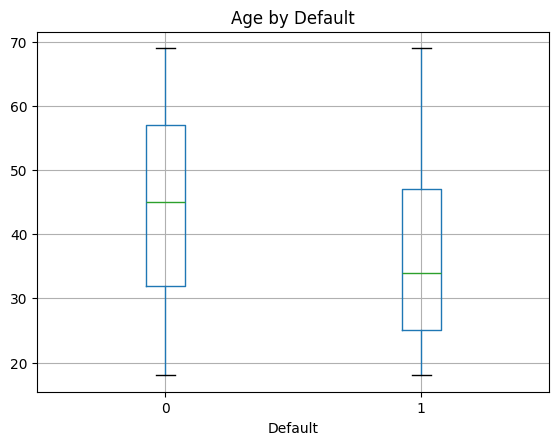

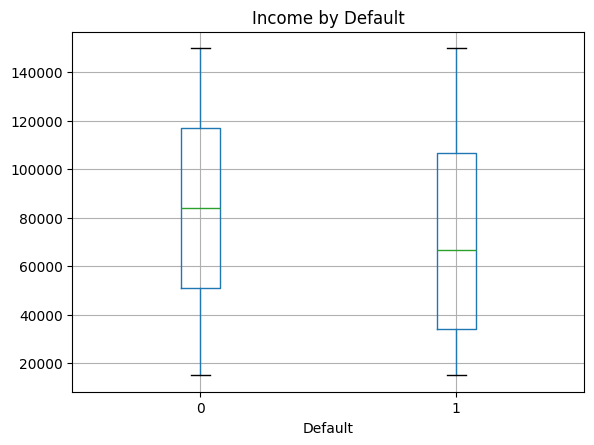

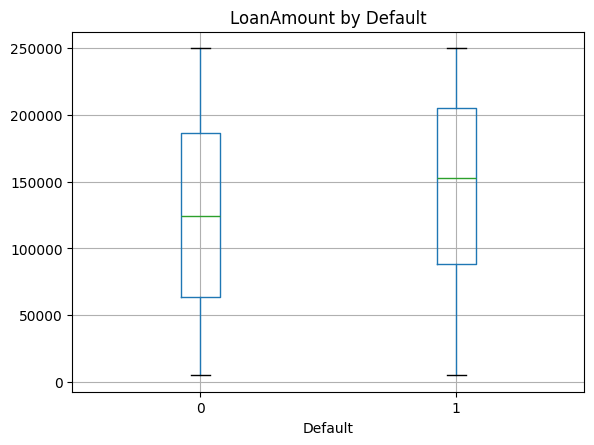

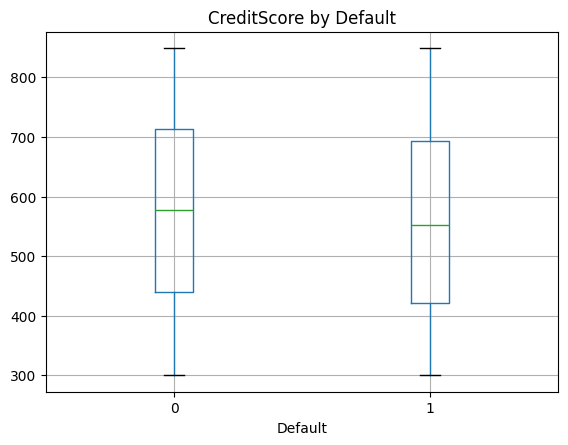

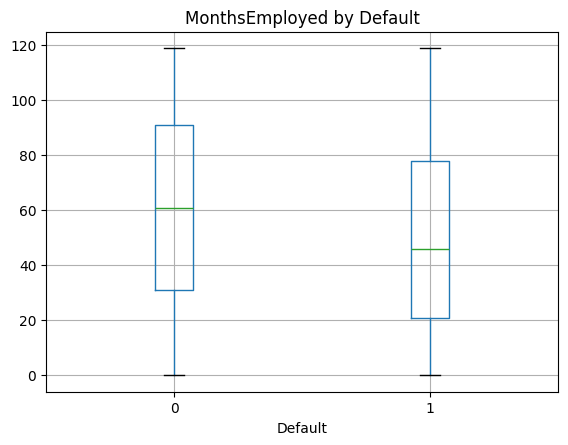

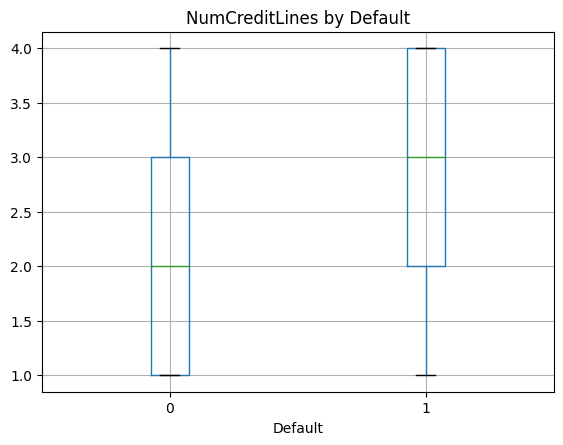

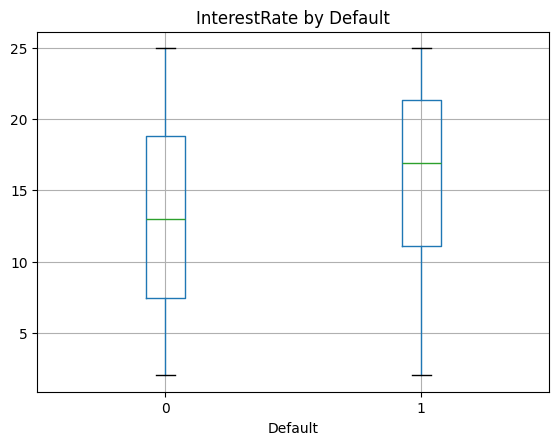

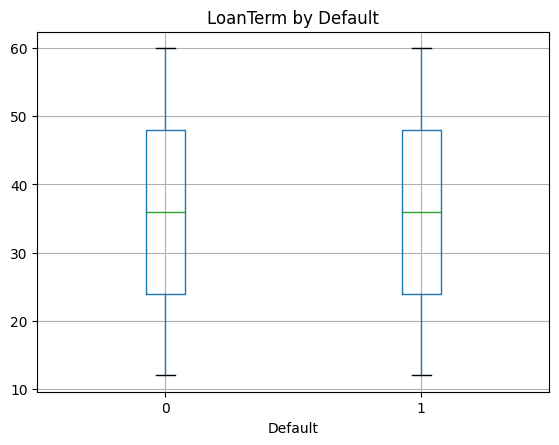

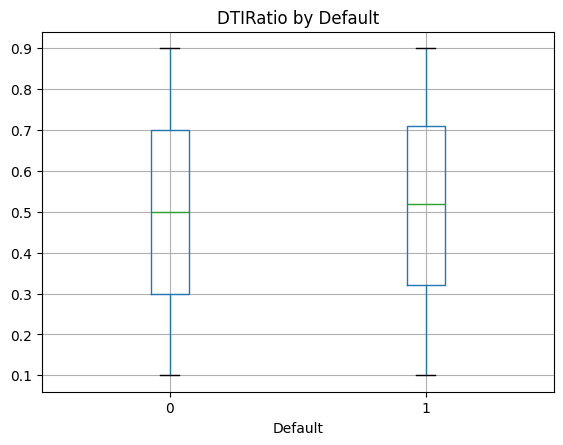

In [42]:
for col in num_cols:
    df.boxplot(column=col, by="Default")
    plt.title(f"{col} by Default")
    plt.suptitle("")
    plt.show()


In [43]:
for col in cat_cols:
    print(f"\n=== {col} vs Default rate ===")
    print(
        df.groupby(col)["Default"]
          .mean()
          .sort_values(ascending=False)
    )



=== Education vs Default rate ===
Education
High School    0.128789
Bachelor's     0.121011
Master's       0.108717
PhD            0.105860
Name: Default, dtype: float64

=== EmploymentType vs Default rate ===
EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64

=== MaritalStatus vs Default rate ===
MaritalStatus
Divorced    0.125328
Single      0.119124
Married     0.103972
Name: Default, dtype: float64

=== HasMortgage vs Default rate ===
HasMortgage
No     0.123451
Yes    0.108806
Name: Default, dtype: float64

=== HasDependents vs Default rate ===
HasDependents
No     0.127244
Yes    0.105024
Name: Default, dtype: float64

=== LoanPurpose vs Default rate ===
LoanPurpose
Business     0.123260
Auto         0.118814
Education    0.118381
Other        0.117885
Home         0.102348
Name: Default, dtype: float64

=== HasCoSigner vs Default rate ===
HasCoSigner
No     0.128661
Yes    0.10360

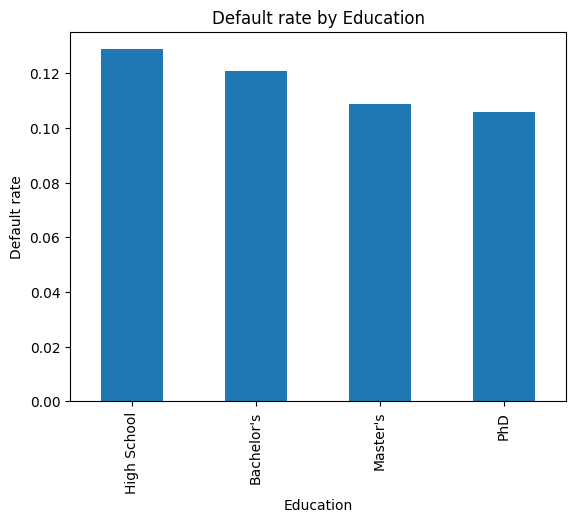

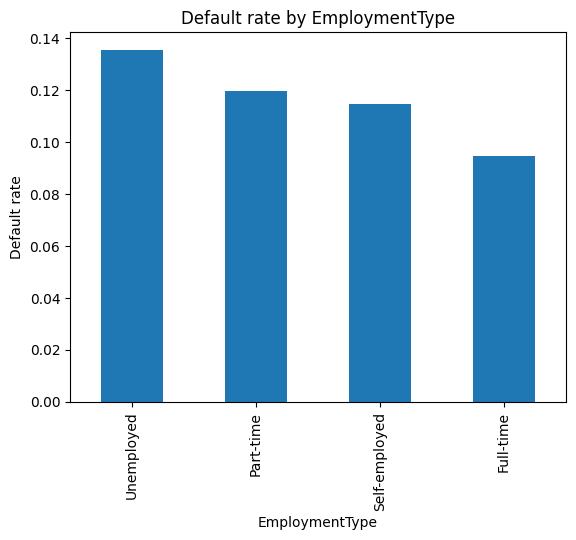

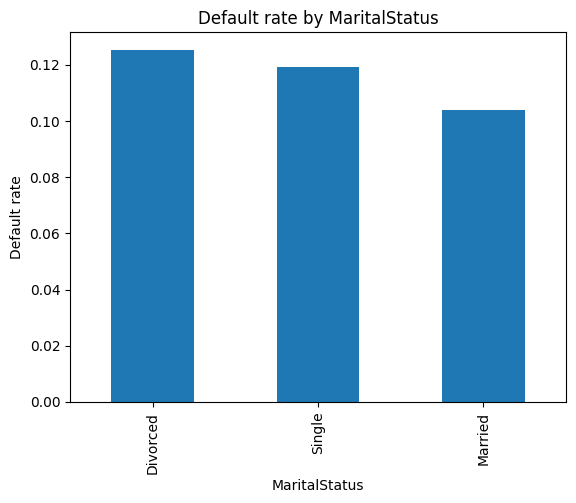

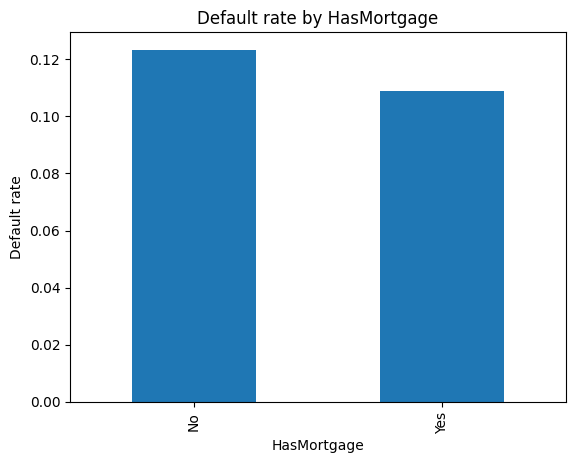

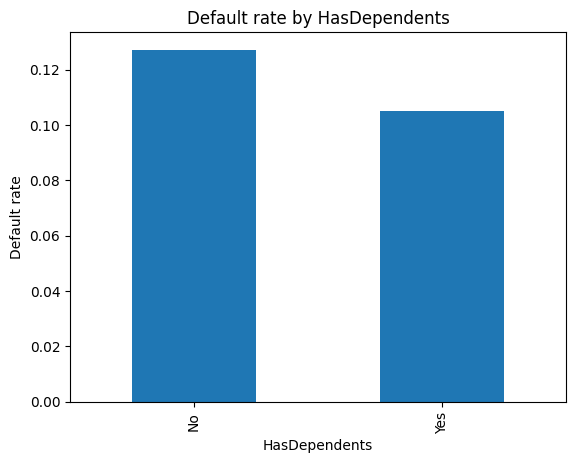

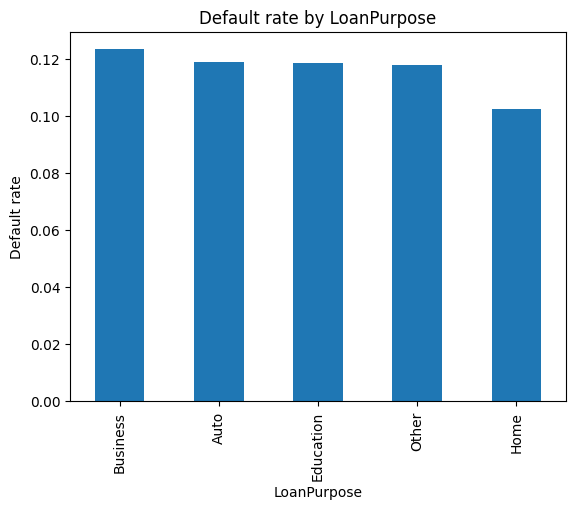

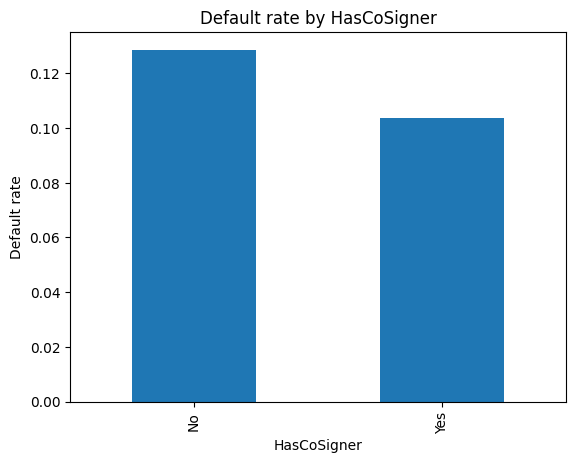

In [44]:
for col in cat_cols:
    avg_default = df.groupby(col)["Default"].mean().sort_values(ascending=False)
    avg_default.plot(kind="bar")
    plt.title(f"Default rate by {col}")
    plt.ylabel("Default rate")
    plt.show()


In [45]:
import numpy as np

corr = df[num_cols + ["Default"]].corr()
corr


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


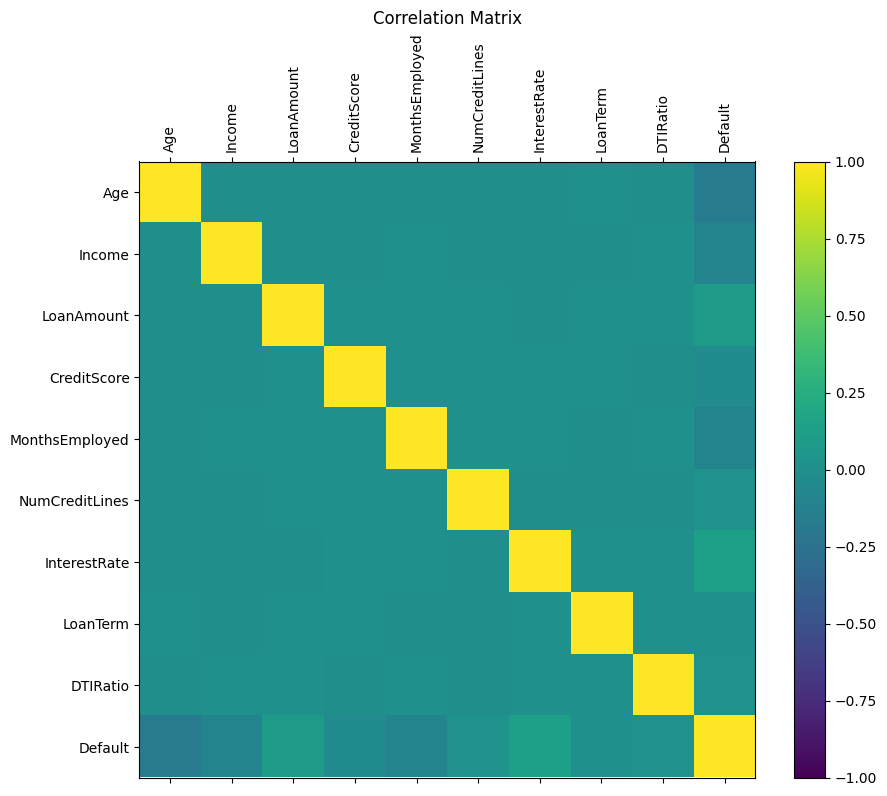

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = range(len(corr.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.title("Correlation Matrix")
plt.show()


In [48]:
def outlier_count(col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

for col in num_cols:
    print(col, "outliers:", outlier_count(col))


Age outliers: 0
Income outliers: 0
LoanAmount outliers: 0
CreditScore outliers: 0
MonthsEmployed outliers: 0
NumCreditLines outliers: 0
InterestRate outliers: 0
LoanTerm outliers: 0
DTIRatio outliers: 0


EDA Summary



The EDA shows that loan default is a rare event, making the dataset highly imbalanced. Borrowers with low credit scores, low incomes, high debt ratios, unstable employment, and lower education levels has higher default risk. Key numerical variables such as CreditScore, Income, and LoanAmount demonstrate meaningful patterns, while categorical features add strong segmentation to the risk profile. Overall, the dataset is clean and suitable for predictive modeling with appropriate handling of class imbalance and feature engineering.